# Lopez-Salido, Stein & Zakrajšek (2017): Replication Walkthrough
## Introduction

Lopez-Salido, Stein, and Zakrajšek (2017, hereafter LSZ) ask whether the
*mood* of the corporate-bond market — not just its level of leverage — helps
forecast the business cycle. Their measure of "credit-market sentiment" is a
two-year-ahead forecast of the change in the Baa-Treasury credit spread,
built from two lagged valuation signals: how narrow the spread already is,
and how large a share of new bond issuance is junk-rated. When that forecast
says spreads are unusually likely to narrow further (sentiment is
elevated and credit is being priced aggressively), real GDP growth over the
following two years is significantly weaker than average. The mechanism the
paper has in mind is mean reversion: frothy pricing does not last, and when
it unwinds, the resulting widening of spreads coincides with a slowdown in activity.

This notebook walks through the part of our codebase that reproduces the
paper's headline exhibits on annual and monthly U.S. data: **Figure I** (the
raw credit spread), **Table I** (a simple one-step forecasting regression),
**Table II** (the paper's two-step sentiment regression), and **Figure II**
(a scatter-plot visualization of Table II's column (1)). We show the code
that builds each exhibit, run it live, and compare our numbers against the
values printed in the published article.

Throughout, every exhibit is produced twice:

| Window | Sample | What it answers |
|---|---|---|
| **Replication** | 1929–2015 | Does our code reproduce the paper's own numbers? |
| **Extended** | 1929–2025 | Does the relationship the paper documents still hold once we push the same construction through the most recent available data? |

The code below follows the methodology described in Sections III.A–III.D of
the paper (pp. 1383–1393). We quote from it accordingly as we go. Each script in the repo is a `doit` task (e.g. `doit replicate_table_1`) and each emits
both windows below for the paper's Baa-Treasury spread.

| Exhibit | Paper section / page | Script | Output |
|---|---|---|---|
| Figure I | III.A, p. 1384 | `replicate_figure_1.py` | `figure_1_*.pdf` |
| Table I | III.B, p. 1386 | `replicate_table_1.py` | `table_1_*.tex` |
| Table II | III.C, p. 1389 | `replicate_table_2.py` | `table_2_*.tex` |
| Figure II | III.D, p. 1392 | `replicate_figure_2.py` | `figure_2_*.pdf` |

## Setup

We import the four `replicate_*` modules directly — these are the same
modules the `doit` pipeline calls, so running their functions here is
exactly what happens when `doit replicate_*` runs, just with
the intermediate objects exposed for inspection.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd().parent / "src"))

import replicate_figure_1 as f1
import replicate_figure_2 as f2
import replicate_table_1 as t1
import replicate_table_2 as t2
from settings import config

PROCESSED_DATA_DIR = Path(config("PROCESSED_DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))

REP_START, REP_END, EXT_END = t1.REP_START, t1.REP_END, t1.EXT_END
print(
    f"Replication window: {REP_START}-{REP_END} \nExtended window: {REP_START}-{EXT_END}"
)


def show_tex(path):
    """The raw LaTeX `emit`/`emit_table_2` write to `_output/` -- exactly
    what feeds `reports/report.tex` -- as a syntax-highlighted, collapsed-
    by-default code block, so it's available without competing with the
    rendered table displayed above it."""
    display(
        Markdown(
            f"<details><summary>Raw LaTeX written to <code>{path.name}</code></summary>\n\n"
            f"```latex\n{path.read_text()}\n```\n</details>"
        )
    )

Replication window: 1929-2015 
Extended window: 1929-2025


## Figure I: The Baa-Treasury Credit Spread

Figure I is the paper's opening exhibit and the raw material behind
everything else: the spread between Moody's seasoned Baa-rated industrial
bond yield and the 10-year Treasury yield, 1925–2015. The paper's own
description (p. 1383) can be seen below:

> "Clearly evident in the figure is the countercyclical nature of credit
> spreads, with spreads generally widening noticeably in advance of and
> during economic downturns."

`replicate_figure_1.plot_figure_1` reads the monthly FRED panel and shades NBER
recessions using the `hist_recession_indicator` column built in
`process_fred_data_monthly.py`.

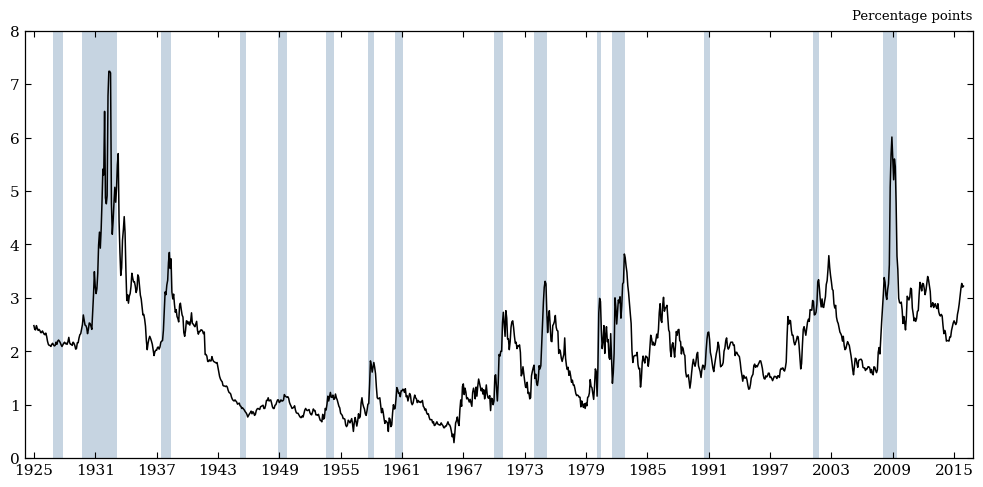

n=1092 months, 1925-01-01 to 2015-12-01


In [2]:
monthly = pd.read_parquet(PROCESSED_DATA_DIR / "fred_final_series_monthly.parquet")

fig_rep, spread_rep = f1.plot_figure_1(monthly, f1.BUFFER_START, f1.REP_END)
plt.show()
print(
    f"n={len(spread_rep)} months, {spread_rep.index.min().date()} to {spread_rep.index.max().date()}"
)

This matches the printed Figure I closely: the Depression-era spike tops out
just above 7 percentage points in 1932, the spread compresses to under 1pp
through the mid-1960s "Great Moderation" prelude, and every NBER recession
band (shaded) lines up with a local spike (1974-75, the double-dip of the
early 1980s, 2001, and the roughly 6pp peak of the 2008–09 financial crisis).

### Extended Window

Pushing the same construction through the most recent available complete year in the 
underlying FRED data (2025) gives us ten more years to look at.

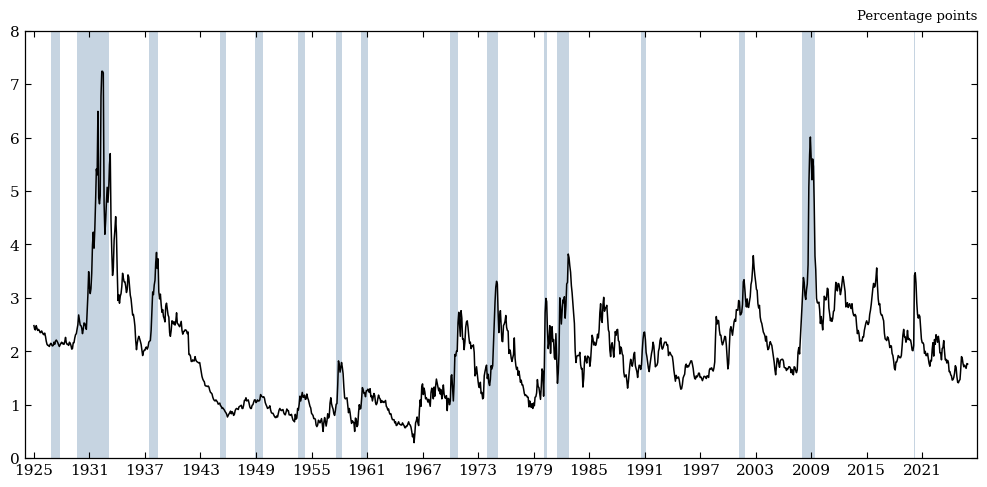

n=1212 months, 1925-01-01 to 2025-12-01


In [3]:
fig_ext, spread_ext = f1.plot_figure_1(monthly, f1.BUFFER_START, f1.EXT_END)
plt.show()
print(
    f"n={len(spread_ext)} months, {spread_ext.index.min().date()} to {spread_ext.index.max().date()}"
)

Three things stand out in the post-2015 tail that weren't in the original
sample:

1. **2020**: a very sharp, very short spike (the NBER recession itself
   lasted only two months, February–April 2020) that is compressed and
   quickly reversed by aggressive Fed intervention, so it appears as a thin
   sliver rather than a wide shaded band like 2008–09.
2. **2016**: a standalone spread widening around the energy-sector
   high-yield stress episode that is **not** flagged as an NBER recession at
   all. This is a useful reminder that the spread is a noisy signal at the
   individual-episode level.
3. **2022–2025**: a brief widening to just above 2.3pp in mid-2022 as the
   Fed's hiking cycle repriced credit risk (again without an NBER recession
   call in this sample), followed by compression back to around 1.4pp by
   late 2024 and a modest partial re-widening toward 1.8–1.9pp through 2025
   — well short of the 2008–09 or Depression-era peaks.

## Table I: Credit Spreads vs. Stock Returns as Growth Predictors
### Definitions

| Code column | Paper symbol | Definition |
|---|---|---|
| `dy_next` (dependent variable) | $\Delta y_t$ | Log-difference of real GDP per capita, year $t-1$ to $t$ |
| `d_credit_spread` | $\Delta s_{t-1}$ | Change in the Baa-Treasury credit spread over year $t-1$ |
| `sp_return` | $r_{t-1}^{SP}$ | S&P 500 total (price + dividend) log return over year $t-1$ |
| `gdp_pc_growth` | $\Delta y_{t-1}$ | Lagged control: real GDP-per-capita growth over year $t-1$ |
| `d_treasury_3mo` | $\Delta i_{t-1}^{(3m)}$ | Change in the 3-month Treasury yield over year $t-1$ |
| `d_treasury_10yr` | $\Delta i_{t-1}^{(10y)}$ | Change in the 10-year Treasury yield over year $t-1$ |
| `CPI_inflation` | $\pi_{t-1}$ | CPI inflation rate over year $t-1$ |
| `const` | — | Regression intercept |

### Regressions

Table I is a simple, one-step warm-up before the paper's real machinery in
Table II. It asks: does last year's change in the credit spread, or last
year's stock return, forecast this year's real GDP-per-capita growth? The
paper's regression (equation (1), p. 1387) is the following:

$$\Delta y_t = \beta_1 \Delta s_{t-1} + \beta_2 r_{t-1}^{SP} + \gamma' \mathbf{x}_{t-1} + \epsilon_t$$

The paper runs this regression 3 times:
1. Using only the credit spread as the independent variable ($\Delta s_{t-1}$)
2. Using only the equity returns as the independent variable ($r_{t-1}^{SP}$)
3. Using both together plus rate/inflation control variables ($\Delta i_{t-1}^{(3m)}$,
$\Delta i_{t-1}^{(10y)}$, $\pi_{t-1}$).

Standard errors are Newey-West (HAC),
using the Newey and West (1994) automatic bandwidth rule
$\lfloor 4(n/100)^{2/9}\rfloor$.

In [4]:
df1 = t1.build_panel()
df1[["d_credit_spread", "sp_return", "gdp_pc_growth", "dy_next"]].tail()

,d_credit_spread,sp_return,gdp_pc_growth,dy_next
year,,,,
2021,-0.40,24.795315,5.770835,1.938786
2022,0.14,-16.107438,1.938786,2.076862
2023,-0.35,19.512526,2.076862,1.866349
2024,-0.21,26.157156,1.866349,1.542263
2025,0.35,14.265114,1.542263,NaN


Column (3) — the paper's headline specification, where credit and equity
compete head-to-head — is worth looking at directly through `statsmodels`
before we get to the formatted table:

In [5]:
res_col3 = t1.run_regression(
    df1,
    [
        "d_credit_spread",
        "sp_return",
        "d_treasury_3mo",
        "d_treasury_10yr",
        "CPI_inflation",
        "gdp_pc_growth",
    ],
    REP_START,
    REP_END,
)
print(res_col3.summary())

                            OLS Regression Results                            
Dep. Variable:                dy_next   R-squared:                       0.492
Model:                            OLS   Adj. R-squared:                  0.453
Method:                 Least Squares   F-statistic:                     19.44
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           8.60e-14
Time:                        22:56:45   Log-Likelihood:                -224.17
No. Observations:                  86   AIC:                             462.3
Df Residuals:                      79   BIC:                             479.5
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.7517      0.473     

`replicate_table_1.emit` runs all three columns and formats them into a LaTeX
table matching the paper's layout (coefficients, HAC standard errors,
significance stars) so the
economic size of the credit and equity channels is directly comparable. We call it for both windows, then display each
table.

In [6]:
t1.emit(df1, REP_START, REP_END, "replication")
t1.emit(df1, REP_START, EXT_END, "extended")

display(t1.pretty_table_1(df1, REP_START, REP_END))
display(t1.pretty_table_1(df1, REP_START, EXT_END))

replication: col1 d_s=-1.958, col2 r_sp=0.075, col3 d_s=-2.124/r_sp=0.022 -> table_1_replication.tex
extended: col1 d_s=-1.871, col2 r_sp=0.069, col3 d_s=-2.033/r_sp=0.017 -> table_1_extended.tex


### Replication vs. Published vs. Extended

With the full tables rendered above, we can also pull their headline
coefficients into a compact side-by-side comparison against the numbers
printed in the paper (Table I, p. 1386):

In [7]:
specs_t1 = {
    "(1)": ["d_credit_spread", "gdp_pc_growth"],
    "(2)": ["sp_return", "gdp_pc_growth"],
    "(3)": [
        "d_credit_spread",
        "sp_return",
        "d_treasury_3mo",
        "d_treasury_10yr",
        "CPI_inflation",
        "gdp_pc_growth",
    ],
}
res_rep_t1 = {
    c: t1.run_regression(df1, r, REP_START, REP_END) for c, r in specs_t1.items()
}
res_ext_t1 = {
    c: t1.run_regression(df1, r, REP_START, EXT_END) for c, r in specs_t1.items()
}

# Published QJE Table I, p. 1386.
published_t1 = {
    "column 1 Δs<sub>t−1</sub>": -1.997,
    "column 2 r<sup>SP</sup><sub>t−1</sub>": 0.081,
    "column 3 Δs<sub>t−1</sub>": -2.061,
    "column 3 r<sup>SP</sup><sub>t−1</sub>": 0.029,
}
compare_t1 = pd.DataFrame(
    {
        "Published QJE": published_t1.values(),
        "Replication (1929-2015)": [
            res_rep_t1["(1)"].params["d_credit_spread"],
            res_rep_t1["(2)"].params["sp_return"],
            res_rep_t1["(3)"].params["d_credit_spread"],
            res_rep_t1["(3)"].params["sp_return"],
        ],
        "Extended (1929-2025)": [
            res_ext_t1["(1)"].params["d_credit_spread"],
            res_ext_t1["(2)"].params["sp_return"],
            res_ext_t1["(3)"].params["d_credit_spread"],
            res_ext_t1["(3)"].params["sp_return"],
        ],
    },
    index=published_t1.keys(),
)
compare_t1["Diff (Replication - Published)"] = (
    compare_t1["Replication (1929-2015)"] - compare_t1["Published QJE"]
)

display(compare_t1.style.format("{:.3f}"))

,Published QJE,Replication (1929-2015),Extended (1929-2025),Diff (Replication - Published)
column 1 Δst−1,-1.997,-1.958,-1.871,0.039
column 2 rSPt−1,0.081,0.075,0.069,-0.006
column 3 Δst−1,-2.061,-2.124,-2.033,-0.063
column 3 rSPt−1,0.029,0.022,0.017,-0.007


Three takeaways:

- **Column (1) and (2) replicate closely.** Credit alone gives us -1.958 vs.
  the paper's -1.997; equity alone gives 0.075 vs. 0.081. The small gaps are
  exactly the kind of thing you'd expect from updated data vintages (FRED
  and Shiller have both revised and re-benchmarked several of these series
  since the research was published).
- **The paper's headline result in column (3) reproduces.** With both
  predictors in the same regression, the credit-spread coefficient barely
  moves (-2.124 vs. published -2.061) and stays highly significant, while
  the equity coefficient collapses toward zero and loses significance - credit beats equities as a
  growth predictor, exactly as the paper argues.
- **The extended window tells the same story, slightly attenuated.** Every
  coefficient keeps its sign and rough magnitude through 2025 (credit column
  (3) comes out to -2.033 vs. -2.124 in the replication window), so the relationship
  isn't an artifact of the specific 1929-2015 sample.

## Table II: The Two-Step Credit-Sentiment Regression
### Definitions

*Second-step (growth) regressions* - dependent variable `dy` ($\Delta y_t$, real GDP-per-capita growth in year $t$):

| Code column | Paper symbol | Definition |
|---|---|---|
| `d_s_hat` | $\Delta \hat s_t$ | Fitted change in the credit spread in year $t$, from the auxiliary spread regression below — the paper's "credit-market sentiment" |
| `r_sp_hat` | $\hat r_t^{SP}$ | Fitted S&P 500 return in year $t$, from the auxiliary return regression below |
| `dy_lag1` | $\Delta y_{t-1}$ | Lagged real GDP-per-capita growth |
| `d_3mo_lag1` | $\Delta i_{t-1}^{(3m)}$ | Lagged change in the 3-month Treasury yield |
| `d_10yr_lag1` | $\Delta i_{t-1}^{(10y)}$ | Lagged change in the 10-year Treasury yield |
| `inflation_pct_lag1` | $\pi_{t-1}$ | Lagged CPI inflation rate |

*Auxiliary (first-step) regressions* - forecast credit-market sentiment two years ahead:

| Code column | Paper symbol | Definition |
|---|---|---|
| `d_spread` (dependent) | $\Delta s_t$ | Realized change in the credit spread in year $t$ |
| `ln_hys_lag2` | $\ln \mathrm{HYS}_{t-2}$ | Log of the high-yield share of bond issuance, two years earlier |
| `spread_lag2` | $s_{t-2}$ | Level of the credit spread, two years earlier |
| `sp_return` (dependent) | $r_t^{SP}$ | Realized S&P 500 total log return in year $t$ |
| `ln_pe10_lag2` | $\ln[P/E10]_{t-2}$ | Log of Shiller's cyclically adjusted P/E ratio, two years earlier |

`d_s_hat` and `r_sp_hat` aren't raw data — they're the fitted values from the two auxiliary regressions, substituted into the second-step regression in place of the realized $\Delta s_t$ and $r_t^{SP}$.

### Regressions

Table II is the paper's central exhibit. Instead of using the realized
change in the credit spread as a regressor (Table I), it uses a forecast
of that change, built two years in advance from lagged valuation signals —
this forecast is what the paper calls "credit-market sentiment." The
construction is a two-step regression (equations (2)-(4), p. 1387):

**Step 1 (auxiliary regressions, twice-lagged predictors):**

$$\Delta s_t = \theta_1 \ln \mathrm{HYS}_{t-2} + \theta_2 s_{t-2} + \nu_t \qquad\qquad r_t^{SP} = \theta_3 \ln[P/E10]_{t-2} + \nu_t'$$

**Step 2 (growth regression on the fitted values):**

$$\Delta y_t = \beta_1 \Delta \hat s_t + \beta_2 \hat r_t^{SP} + \gamma' \mathbf{x}_{t-1} + \epsilon_t$$

Economically, $\ln \mathrm{HYS}_{t-2}$ is the (log) high-yield share of bond
issuance two years ago, and $s_{t-2}$ is the level of the spread two years
ago - both from `01_summary_statistics.ipynb`'s Greenwood-Hanson and FRED
sections. When issuance quality was low and spreads were already narrow two
years ago, the auxiliary regression predicts spreads will widen this year;
that widening ($\Delta \hat s_t$) is what step 2 uses to forecast growth.

`build_panel` assembles all three source files into one annual panel.

In [8]:
df2 = t2.build_panel()
df2[
    ["dy", "d_spread", "sp_return", "ln_hys_lag2", "spread_lag2", "ln_pe10_lag2"]
].tail()

,dy,d_spread,sp_return,ln_hys_lag2,spread_lag2,ln_pe10_lag2
year,,,,,,
2021,5.770835,-0.40,24.795315,-1.362855,2.02,3.412197
2022,1.938786,0.14,-16.107438,-1.581155,2.23,3.519442
2023,2.076862,-0.35,19.512526,-1.219836,1.83,3.645577
2024,1.866349,-0.21,26.157156,-2.072290,1.97,3.343459
2025,1.542263,0.35,14.265114,-1.910751,1.62,3.448472


`run_table_2` fits the two auxiliary regressions and the four second-step
growth columns — (1) spread sentiment
only, (2) equity sentiment only, (3) both, (4) spread sentiment plus
macro controls — and `emit_table_2` writes the formatted LaTeX and prints a
diagnostic summary, exactly like the `doit replicate_table_2` task does. As
with Table I, we then display each table rendered.

In [9]:
res2_rep = t2.run_table_2(df2, REP_START, REP_END)
t2.emit_table_2(res2_rep, REP_START, REP_END, "replication")

main_rep, aux_rep = t2.pretty_table_2(res2_rep, REP_START, REP_END)
display(main_rep)
display(aux_rep)

replication (1929-2015):
  (1) N=84 R2=0.377 d_s_hat=-4.281, dy_lag1=0.597
  (2) N=85 R2=0.337 r_sp_hat=0.145, dy_lag1=0.534
  (3) N=84 R2=0.380 d_s_hat=-3.861, r_sp_hat=0.053, dy_lag1=0.590
  (4) N=84 R2=0.394 d_s_hat=-4.907, dy_lag1=0.581, d_3mo_lag1=0.099, d_10yr_lag1=-0.616, inflation_pct_lag1=0.123
  aux Delta s_t: N=84 R2=0.102 ln_hys_lag2=0.147 spread_lag2=-0.245
  aux r_t^SP:    N=85 R2=0.083 ln_pe10_lag2=-13.171
  -> table_2_replication.tex


,Δst,rSPt
ln HYSt−2,0.147***,---
,(0.042),
st−2,-0.245***,---
,(0.047),
ln[P/E10]t−2,---,-0.132***
,,(0.040)
R²,0.102,0.083


In [10]:
res2_ext = t2.run_table_2(df2, REP_START, EXT_END)
t2.emit_table_2(res2_ext, REP_START, EXT_END, "extended")

main_ext, aux_ext = t2.pretty_table_2(res2_ext, REP_START, EXT_END)
display(main_ext)
display(aux_ext)

extended (1929-2025):
  (1) N=94 R2=0.353 d_s_hat=-4.271, dy_lag1=0.577
  (2) N=95 R2=0.313 r_sp_hat=0.176, dy_lag1=0.516
  (3) N=94 R2=0.356 d_s_hat=-3.884, r_sp_hat=0.068, dy_lag1=0.570
  (4) N=94 R2=0.368 d_s_hat=-4.900, dy_lag1=0.559, d_3mo_lag1=0.117, d_10yr_lag1=-0.603, inflation_pct_lag1=0.121
  aux Delta s_t: N=94 R2=0.096 ln_hys_lag2=0.130 spread_lag2=-0.244
  aux r_t^SP:    N=95 R2=0.047 ln_pe10_lag2=-9.090
  -> table_2_extended.tex


,Δst,rSPt
ln HYSt−2,0.130***,---
,(0.039),
st−2,-0.244***,---
,(0.046),
ln[P/E10]t−2,---,-0.091***
,,(0.035)
R²,0.096,0.047


### Replication vs. Published vs. Extended

With the full tables rendered above, we pull their headline coefficients —
both the second-step growth regression and the two first-step auxiliary
regressions — into a compact comparison against the paper's published
numbers (Table II, p. 1389):

In [11]:
# Published QJE Table II, p. 1389.
published_t2_main = {
    "column 1 Δŝ<sub>t</sub>": -4.800,
    "column 2 r̂<sup>SP</sup><sub>t</sub>": 0.145,
    "column 3 Δŝ<sub>t</sub>": -4.409,
    "column 3 r̂<sup>SP</sup><sub>t</sub>": 0.069,
    "column 4 Δŝ<sub>t</sub>": -5.389,
}
compare_t2_main = pd.DataFrame(
    {
        "Published QJE": published_t2_main.values(),
        "Replication (1929-2015)": [
            res2_rep["col1"].params["d_s_hat"],
            res2_rep["col2"].params["r_sp_hat"],
            res2_rep["col3"].params["d_s_hat"],
            res2_rep["col3"].params["r_sp_hat"],
            res2_rep["col4"].params["d_s_hat"],
        ],
        "Extended (1929-2025)": [
            res2_ext["col1"].params["d_s_hat"],
            res2_ext["col2"].params["r_sp_hat"],
            res2_ext["col3"].params["d_s_hat"],
            res2_ext["col3"].params["r_sp_hat"],
            res2_ext["col4"].params["d_s_hat"],
        ],
    },
    index=published_t2_main.keys(),
)
compare_t2_main["Diff (Replication - Published)"] = (
    compare_t2_main["Replication (1929-2015)"] - compare_t2_main["Published QJE"]
)

print("Second-step (growth) regression:")
display(compare_t2_main.style.format("{:.3f}"))

# Published QJE Table II auxiliary regressions, p. 1389.
# ln[P/E10]_{t-2}'s fitted coefficient is ~100x the paper's display convention
# (see the `_AUX_ROWS` comment in replicate_table_2.py); we apply the same 0.01
# display rescaling here for a fair comparison.
published_t2_aux = {
    "ln HYS<sub>t−2</sub>": 0.095,
    "s<sub>t−2</sub>": -0.248,
    "ln[P/E10]<sub>t−2</sub>": -0.134,
}
compare_t2_aux = pd.DataFrame(
    {
        "Published QJE": published_t2_aux.values(),
        "Replication (1929-2015)": [
            res2_rep["aux_spread"].params["ln_hys_lag2"],
            res2_rep["aux_spread"].params["spread_lag2"],
            res2_rep["aux_return"].params["ln_pe10_lag2"] * 0.01,
        ],
        "Extended (1929-2025)": [
            res2_ext["aux_spread"].params["ln_hys_lag2"],
            res2_ext["aux_spread"].params["spread_lag2"],
            res2_ext["aux_return"].params["ln_pe10_lag2"] * 0.01,
        ],
    },
    index=published_t2_aux.keys(),
)
compare_t2_aux["Diff (Replication - Published)"] = (
    compare_t2_aux["Replication (1929-2015)"] - compare_t2_aux["Published QJE"]
)

print("\nFirst-step (auxiliary) regressions:")
display(compare_t2_aux.style.format("{:.3f}"))

Second-step (growth) regression:


,Published QJE,Replication (1929-2015),Extended (1929-2025),Diff (Replication - Published)
column 1 Δŝt,-4.800,-4.281,-4.271,0.519
column 2 r̂SPt,0.145,0.145,0.176,-0.000
column 3 Δŝt,-4.409,-3.861,-3.884,0.548
column 3 r̂SPt,0.069,0.053,0.068,-0.016
column 4 Δŝt,-5.389,-4.907,-4.900,0.482



First-step (auxiliary) regressions:


,Published QJE,Replication (1929-2015),Extended (1929-2025),Diff (Replication - Published)
ln HYSt−2,0.095,0.147,0.130,0.052
st−2,-0.248,-0.245,-0.244,0.003
ln[P/E10]t−2,-0.134,-0.132,-0.091,0.002


Three takeaways:

- **Column (2) is essentially exact**: 0.145 in both the paper and our
  replication. Column (1)'s credit-sentiment coefficient (-4.281 vs.
  published -4.800) and column (4) (-4.907 vs. -5.389) are within about
  10% — same sign, same order of magnitude, same conclusion (credit-market
  sentiment two years ago has a large, negative, statistically significant
  effect on growth today).
- **The auxiliary regressions confirm the mechanism**: $s_{t-2}$ predicts
  mean reversion in the spread almost exactly as published (-0.245 vs.
  -0.248), and $\ln[P/E10]_{t-2}$'s coefficient (-0.132) sits right
  on top of the paper's -0.134. $\ln \mathrm{HYS}_{t-2}$ is the one
  meaningfully different auxiliary coefficient (0.147 vs. published 0.095). In this case,
  the Greenwood-Hanson high-yield share
  we pull is a newer, revised vintage of that series than the one the
  authors used in 2017, which is the most likely source of this gap.
- **The extended window changes very little in the main regression**
  (column (1) results in -4.271 vs. -4.281), but the equity-sentiment auxiliary
  regression's $R^2$ drops noticeably (0.083 → 0.047, and its coefficient
  from -0.132 to -0.091) — CAPE became a weaker within-sample predictor of
  next-year equity returns once the low-rate, high-valuation 2016-2025 era
  is folded in, a pattern consistent with well-documented critiques of
  Shiller CAPE's predictive power in this more recent period.

## Figure II: Credit-Market Sentiment and Growth

Figure II (p. 1392) is a visualization of Table II's column (1): it plots
credit-market sentiment at $t-2$ against real GDP-per-capita growth at $t$,
both orthogonalized against column (1)'s other regressor
($\Delta y_{t-1}$), with the fitted line's slope equal to column (1)'s
$\beta$ on $\Delta \hat s_t$.

`replicate_figure_2.orthogonalize` implements this. The paper also flags a handful of
"influential observations" and so does `find_influential`, using the same rule the paper
applies in its own Figure III discussion (p. 1393).

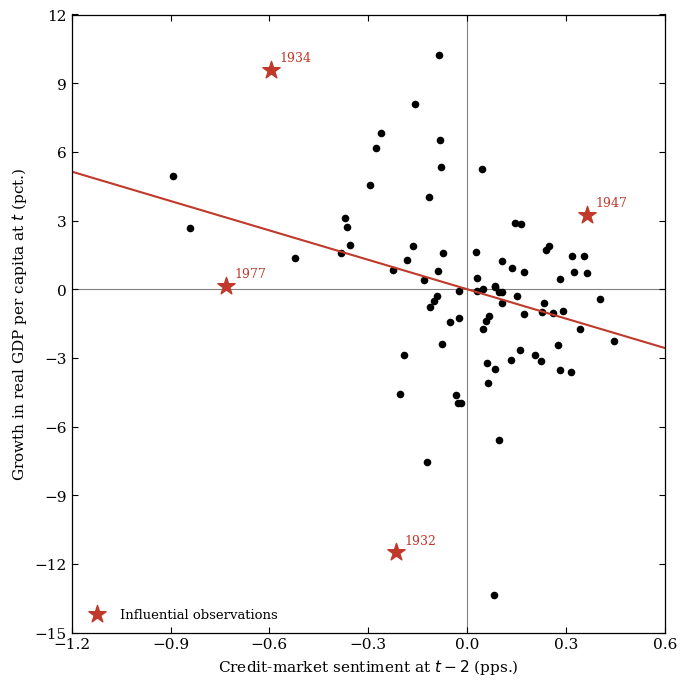

In [12]:
fig2_rep = f2.plot_figure_2(df2, REP_START, REP_END)
plt.show()

Compared with the printed Figure II, the negative slope, the spread of
points, and even the specific years flagged as influential are all a close
match — the paper calls out **1932, 1934, and 1977** as its three most
influential observations; our replication flags those same three, plus a
fourth, **1947**. This extra flagged year is most likely a data-vintage artifact rather than a
methodology difference. It's a
good example of a "close but not pixel-identical" replication result, and
worth naming rather than papering over.

### Extended Window

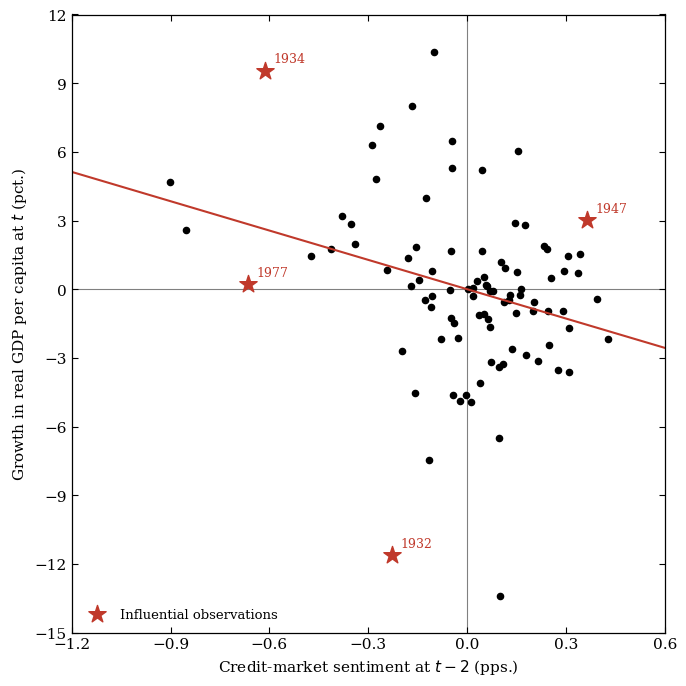

In [13]:
fig2_ext = f2.plot_figure_2(df2, REP_START, EXT_END)
plt.show()

Visually the two figures are nearly indistinguishable — most of the ten
additional (2016-2025) points cluster close to the origin on both axes,
consistent with the muted post-2015 spread swings we saw in the extended
Figure I. We can make the "nearly indistinguishable" claim concrete rather
than just visual:

In [14]:
beta_rep = res2_rep["col1"].params["d_s_hat"]
beta_ext = res2_ext["col1"].params["d_s_hat"]
infl_rep = sorted(f2.find_influential(res2_rep["col1"], "d_s_hat"))
infl_ext = sorted(f2.find_influential(res2_ext["col1"], "d_s_hat"))

print(f"Fitted slope, replication window: {beta_rep:.3f}")
print(f"Fitted slope, extended window:    {beta_ext:.3f}")
print(f"Influential years, replication window: {infl_rep}")
print(f"Influential years, extended window:    {infl_ext}")
print("Same influential years in both windows:", infl_rep == infl_ext)

Fitted slope, replication window: -4.281
Fitted slope, extended window:    -4.271
Influential years, replication window: [1932, 1934, 1947, 1977]
Influential years, extended window:    [1932, 1934, 1947, 1977]
Same influential years in both windows: True


The fitted slope moves by less than 0.3%, and the same four years remain the
influential ones — no observation from 2016-2025, including the extreme 2020
pandemic growth print, crosses the cutoff to be considered an influential observation.
That's a meaningful robustness result on its own: even the
sharpest GDP shock in the extended sample doesn't look unusual once we
condition on the credit-sentiment/growth relationship the paper documents —
it's a big move in $y$, but not a big *surprise* relative to what
credit-market sentiment two years earlier and last year's growth already
implied.

## Summary

| Exhibit | Replicates published paper? | Holds up through 2025? |
|---|---|---|
| Figure I | Yes, recession-timed spikes match at every date, exact prefix match with the extended series | Yes, same pattern continues, with a sharp-but-brief 2020 spike and a 2022 widening that fades by 2024 |
| Table I | Yes, closely — column 3's "credit beats equities" result reproduces (credit stays significant, equity collapses) | Yes, with mild attenuation (credit coefficient -2.124 → -2.033) |
| Table II | Yes, especially column 2 (0.145 vs. published 0.145) and the auxiliary $s_{t-2}$/$\ln[P/E10]_{t-2}$ rows; columns 1 and 4 within ~10% | Yes, the main coefficients nearly unchanged; CAPE's auxiliary predictive power weakens noticeably |
| Figure II | Yes, same slope, same three published influential years plus one data-vintage-driven fourth (1947) | Yes, fitted slope and influential year set both essentially unchanged |

Across all four exhibits, our replication of Lopez-Salido, Stein &
Zakrajšek (2017) using the Baa-Treasury spread reproduces the paper's
central claim - that elevated credit-market sentiment two years prior
forecasts materially weaker subsequent growth. We see this in both the original
1929-2015 sample and after extending the same construction through 2025.
The remaining gaps from the published numbers are small.